# Интерпретация. Практическая работа

## Цель практической работы

Научиться интерпретировать модели кластеризации.

## Что входит в практическую работу


1. Загрузить данные и провести разведочный анализ.
2. Предположить оптимальное количество кластеров.
3. Очистить и подготовить данные для использования в моделях машинного обучения.
4. Построить модель кластеризации с помощью библиотеки Scikit-learn и вычислить оптимальное количество кластеров.
5. Визуализировать результаты кластеризации.
6. Интерпретировать полученные результаты.
7. Подкрепить выводы интерпретации визуализациями.

## Что оценивается 

* Выполнены все этапы работы.
* Сделаны выводы по результатам разведочного анализа данных.
* Выполнена и обоснована подготовка данных.
* Выбор количества кластеров обоснован и подкреплён визуализацией. 
* Выбор гиперпараметров метода понижения размерности обоснован.
* Интерпретация кластеров подкреплена расчётами и визуализацией. 



# Задача

У вас имеется некоторый набор данных `marketing_campaign.csv` о покупателях супермаркета.

* ID — уникальный идентификатор клиента.
* Year_Birth — год рождения клиента.
* Dt_Customer — дата регистрации клиента на сайте.
* Recency — количество дней с момента последней покупки клиента.
* MntFruits — сумма, потраченная на фрукты за последние два года.
* MntMeatProducts — сумма, потраченная на мясо за последние два года.
* MntFishProducts — сумма, потраченная на рыбу за последние два года.
* MntSweetProducts — сумма, потраченная на сладости за последние два года.
* NumWebPurchases — количество покупок, совершённых через сайт.
* NumStorePurchases — количество покупок, совершённых непосредственно в магазинах.
* Response: 1, если клиент участвовал в последней рекламной кампании, 0 — в противном случае.

Решите задачу кластеризации покупателей, чтобы в дальнейшем планировать маркетинговые акции для каждой группы покупателей. Подготовьте результаты своей работы для демонстрации заказчику, не погружённому в машинное обучение.

# Задание 1

Загрузите датасет и выполните разведочный анализ данных. Сделайте выводы о найденных закономерностях, особенностях и других свойствах данных, которые вы обнаружите.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler

import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv('marketing_campaign.csv')
df.head()


,ID,Year_Birth,Dt_Customer,Recency,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,NumWebPurchases,NumStorePurchases,Response
0,5524,1957,04-09-2012,58,88,546,172,88,8,4,1
1,2174,1954,08-03-2014,38,1,6,2,1,1,2,0
2,4141,1965,21-08-2013,26,49,127,111,21,8,10,0
3,6182,1984,10-02-2014,26,4,20,10,3,2,4,0
4,5324,1981,19-01-2014,94,43,118,46,27,5,6,0


In [3]:
df.isnull().sum()


ID                   0
Year_Birth           0
Dt_Customer          0
Recency              0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
NumWebPurchases      0
NumStorePurchases    0
Response             0
dtype: int64

In [4]:
df.describe()

,ID,Year_Birth,Recency,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,NumWebPurchases,NumStorePurchases,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,49.109375,26.302232,166.950000,37.525446,27.062946,4.084821,5.790179,0.149107
std,3246.662198,11.984069,28.962453,39.773434,225.715373,54.628979,41.280498,2.778714,3.250958,0.356274
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,24.000000,1.000000,16.000000,3.000000,1.000000,2.000000,3.000000,0.000000
50%,5458.500000,1970.000000,49.000000,8.000000,67.000000,12.000000,8.000000,4.000000,5.000000,0.000000
75%,8427.750000,1977.000000,74.000000,33.000000,232.000000,50.000000,33.000000,6.000000,8.000000,0.000000
max,11191.000000,1996.000000,99.000000,199.000000,1725.000000,259.000000,263.000000,27.000000,13.000000,1.000000


In [5]:
df.dtypes

ID                    int64
Year_Birth            int64
Dt_Customer          object
Recency               int64
MntFruits             int64
MntMeatProducts       int64
MntFishProducts       int64
MntSweetProducts      int64
NumWebPurchases       int64
NumStorePurchases     int64
Response              int64
dtype: object

Histogram for ID


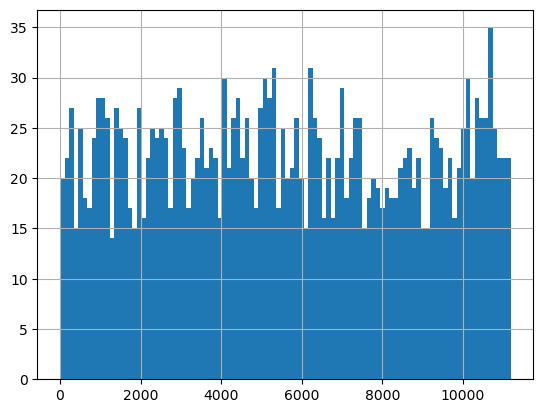

Histogram for Year_Birth


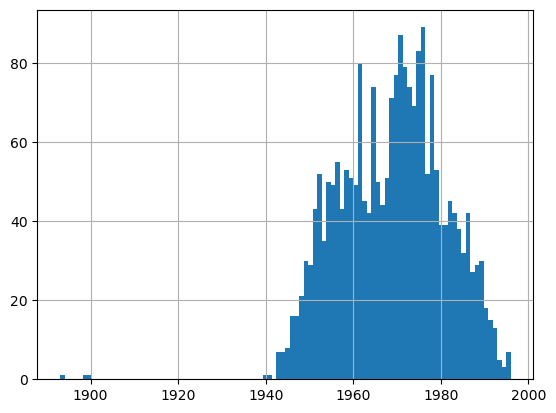

Histogram for Recency


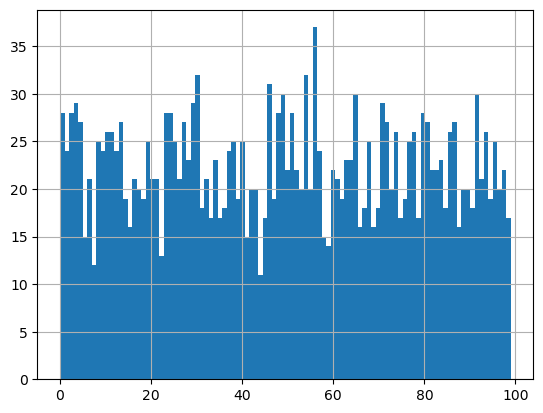

Histogram for MntFruits


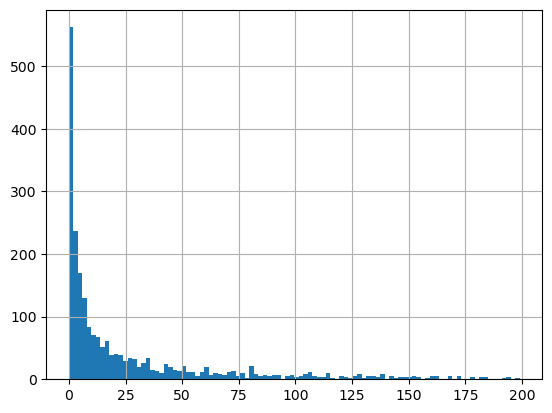

Histogram for MntMeatProducts


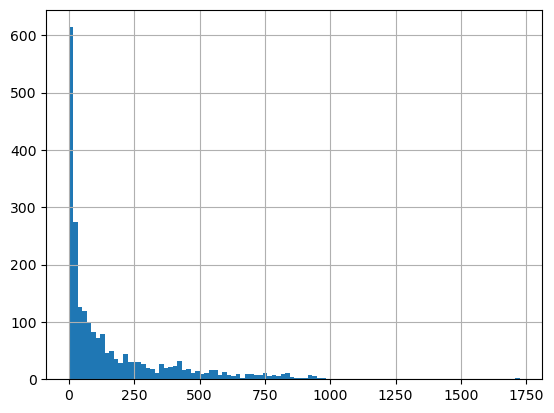

Histogram for MntFishProducts


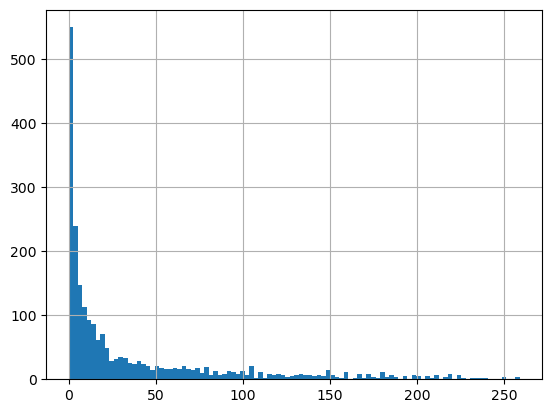

Histogram for MntSweetProducts


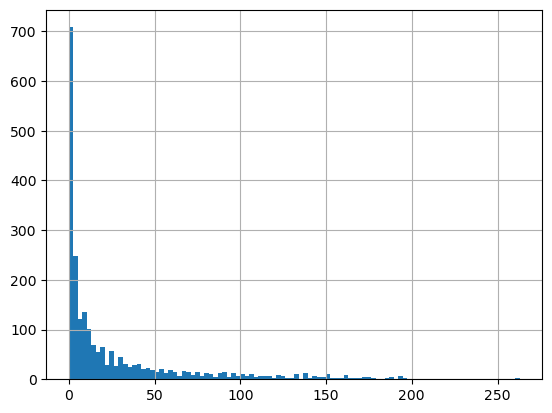

Histogram for NumWebPurchases


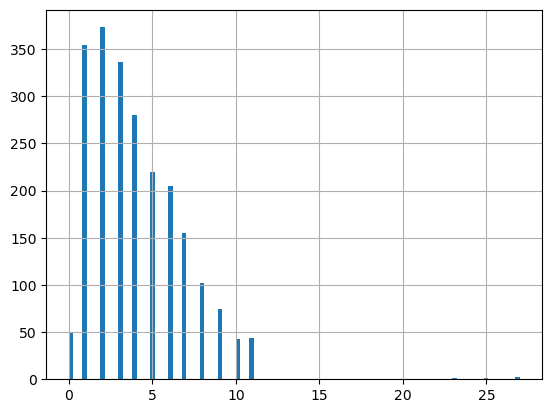

Histogram for NumStorePurchases


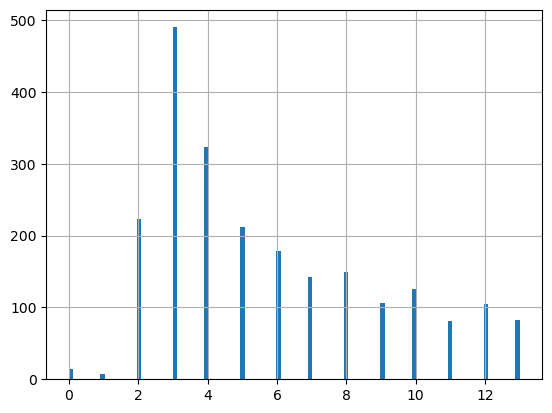

Histogram for Response


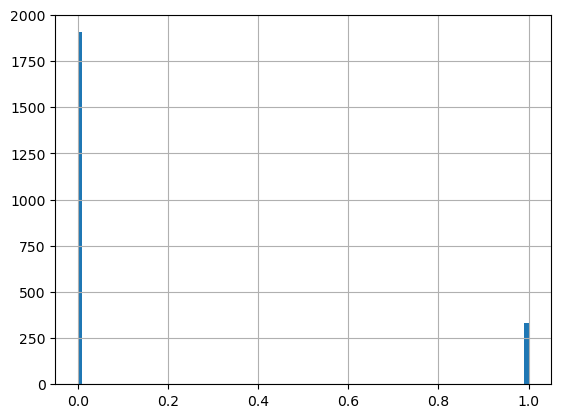

In [6]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_features:
  print(f'Histogram for {col}')
  df[col].hist(bins=100)
  plt.show()

In [7]:
#преобразуем признак Dt_Customer в количество дней с начала эпохи
from datetime import datetime, date
df_new = df.copy()

df_new['Dt_Customer'] = pd.to_datetime(df_new['Dt_Customer'], utc=True)  # Convert to tz-aware datetime
df_new['days_from_1970'] = df_new['Dt_Customer'].apply(lambda x: (x - pd.Timestamp('1970-01-01', tz='UTC')).days)
df_new = df_new.drop(['Dt_Customer'], axis=1)

In [8]:
df

,ID,Year_Birth,Dt_Customer,Recency,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,NumWebPurchases,NumStorePurchases,Response
0,5524,1957,04-09-2012,58,88,546,172,88,8,4,1
1,2174,1954,08-03-2014,38,1,6,2,1,1,2,0
2,4141,1965,21-08-2013,26,49,127,111,21,8,10,0
3,6182,1984,10-02-2014,26,4,20,10,3,2,4,0
4,5324,1981,19-01-2014,94,43,118,46,27,5,6,0
...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,13-06-2013,46,43,182,42,118,9,4,0
2236,4001,1946,10-06-2014,56,0,30,0,0,8,5,0
2237,7270,1981,25-01-2014,91,48,217,32,12,2,13,0
2238,8235,1956,24-01-2014,8,30,214,80,30,6,10,0


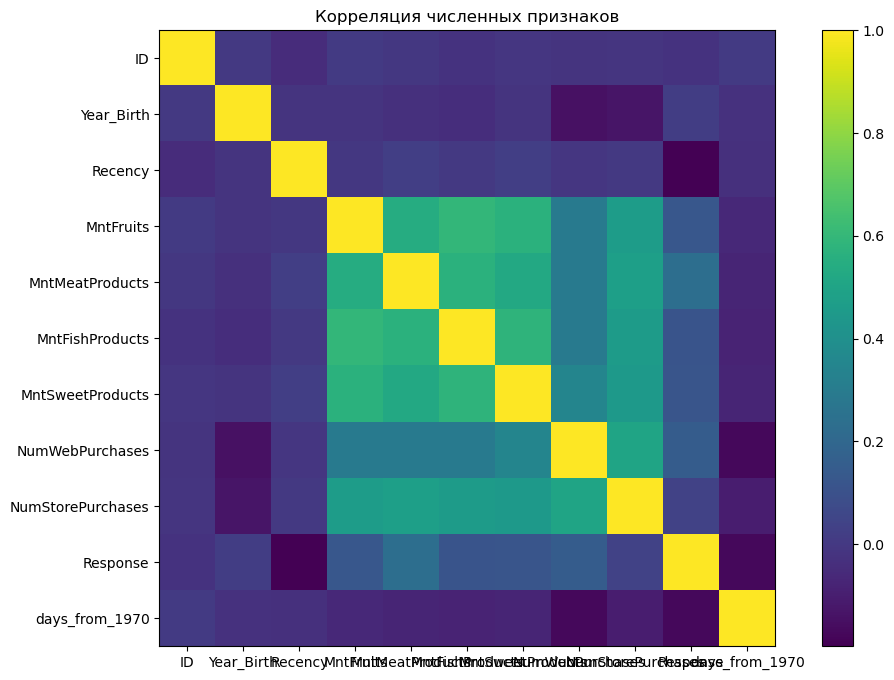

In [9]:
plt.figure(figsize=(12, 8))

columns = df_new.corr().columns.tolist()
plt.imshow(df_new.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

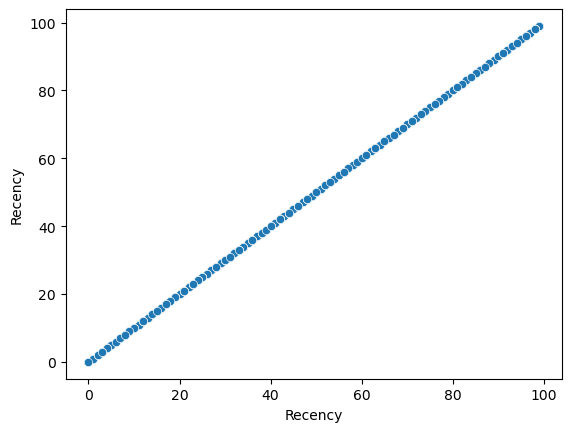

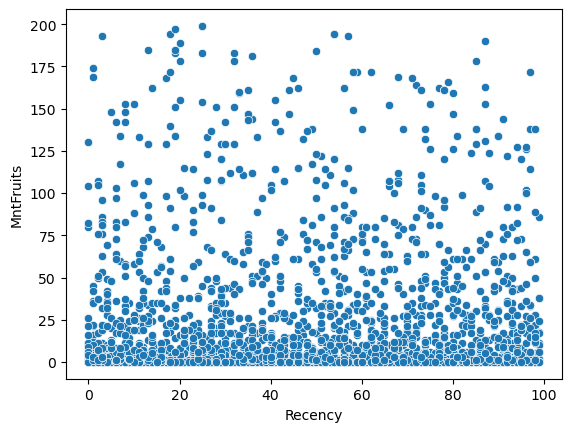

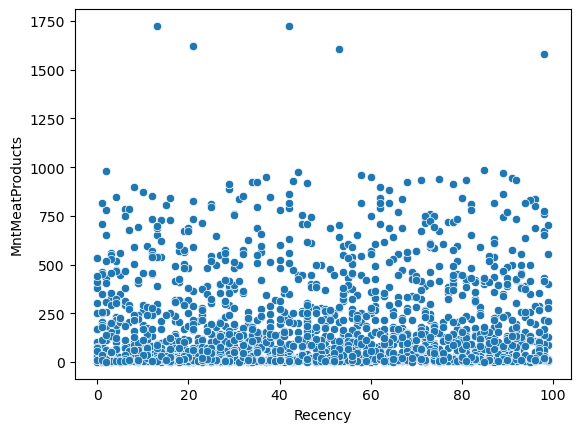

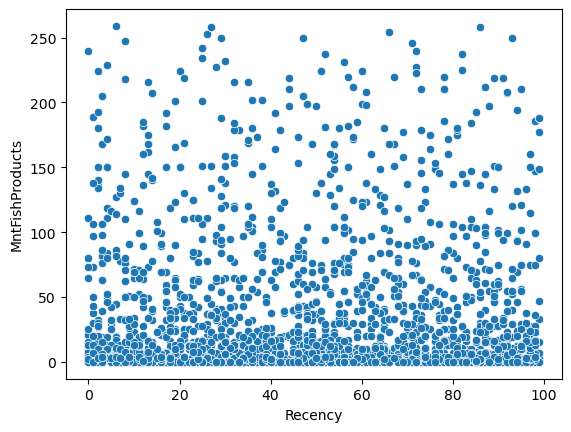

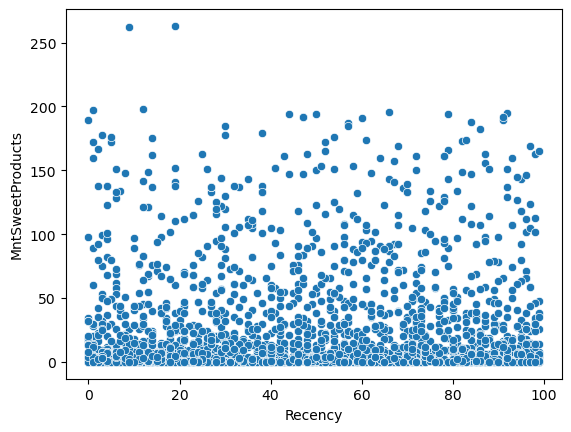

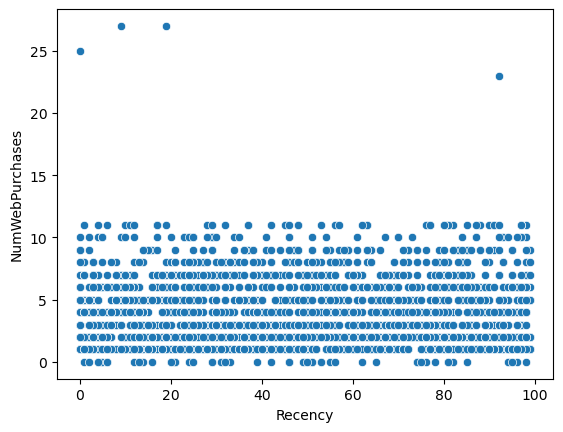

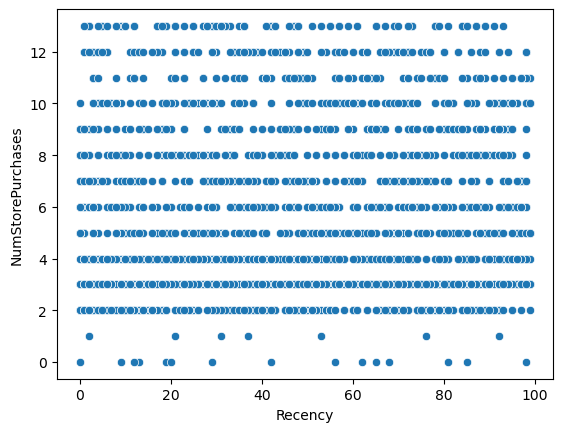

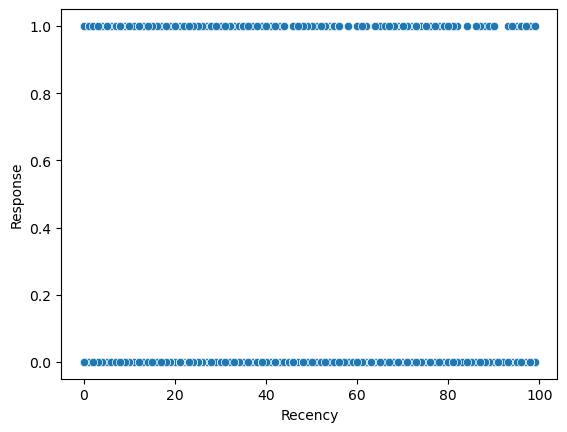

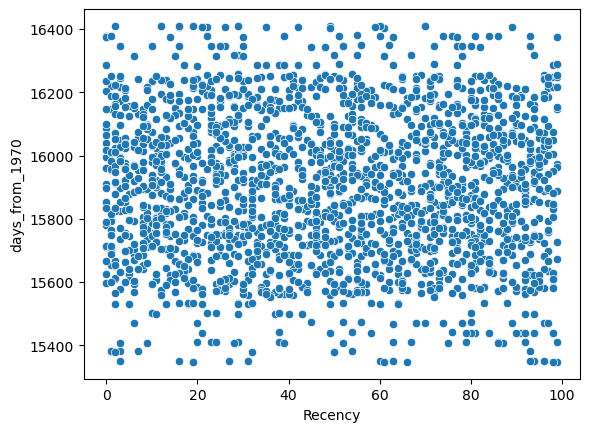

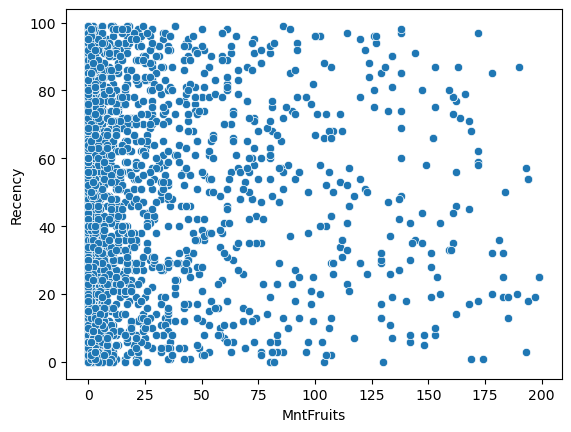

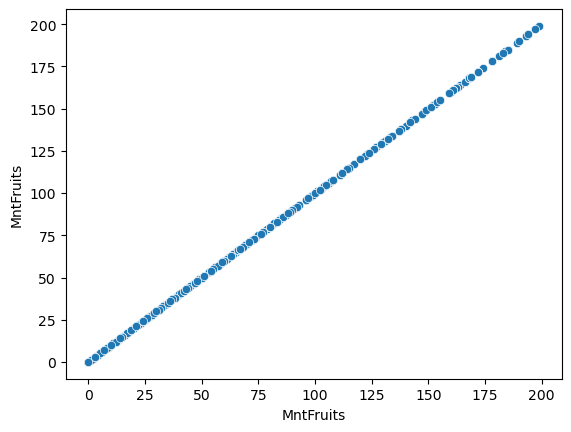

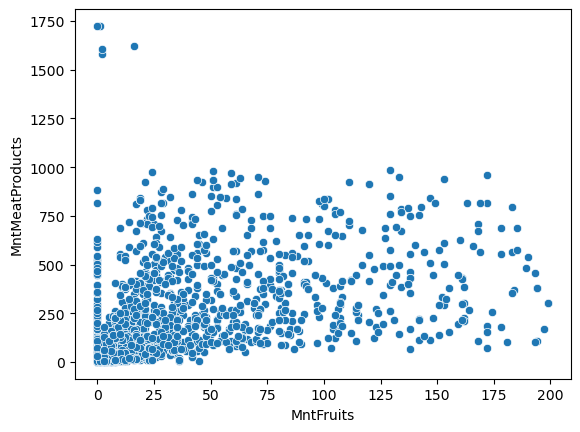

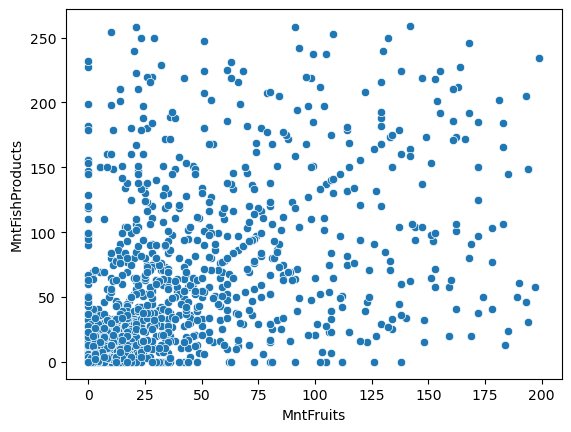

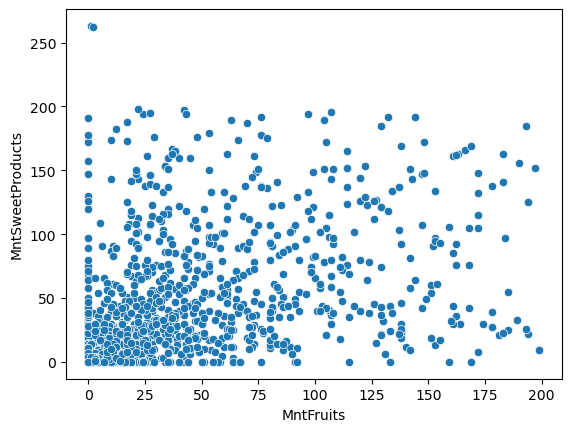

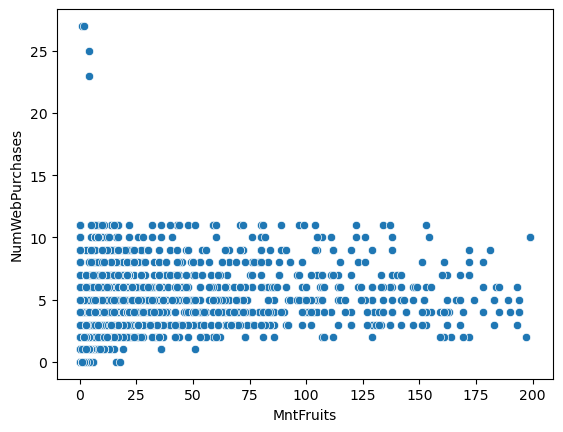

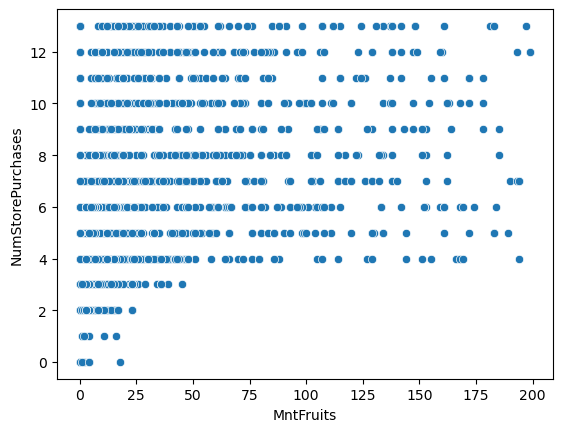

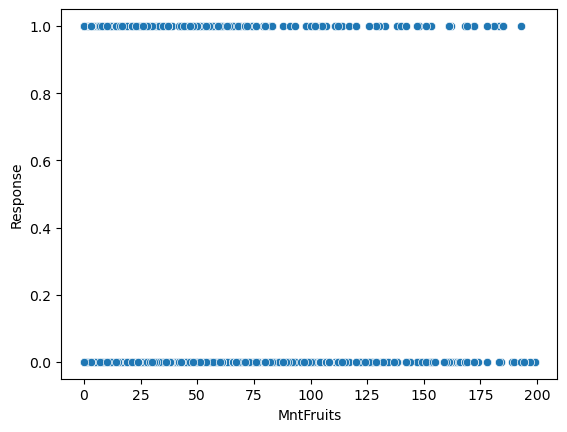

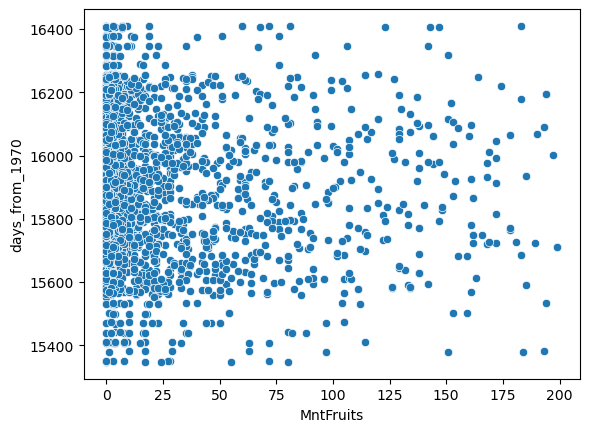

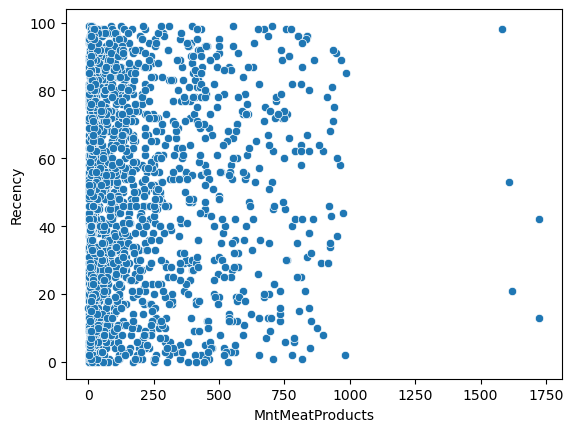

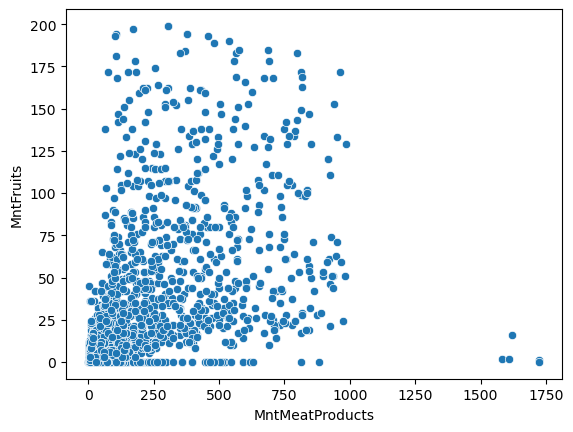

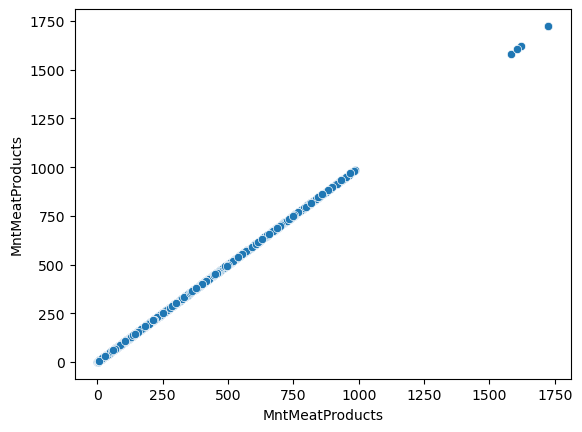

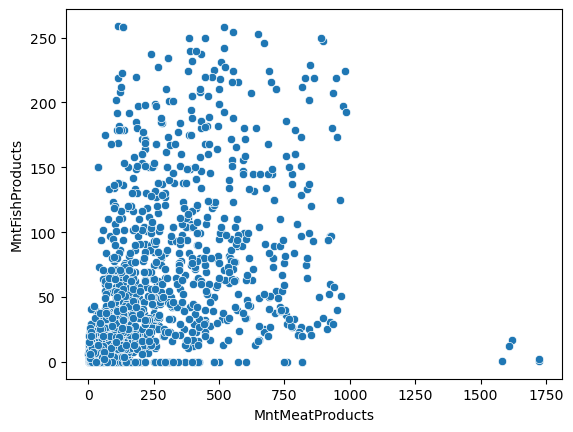

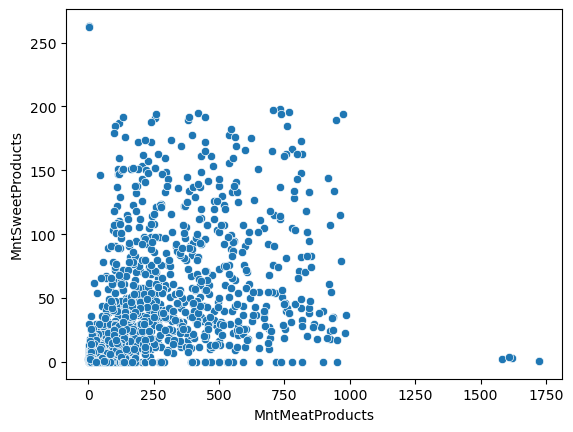

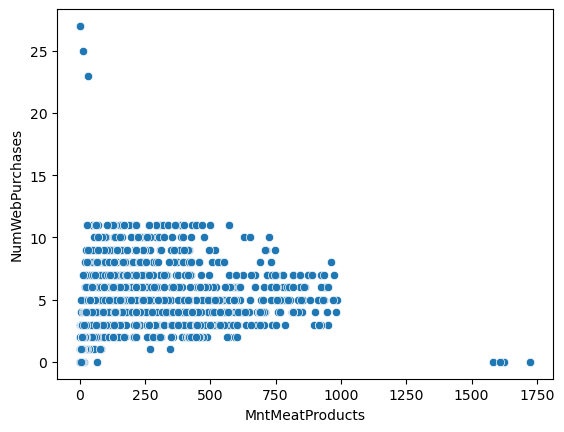

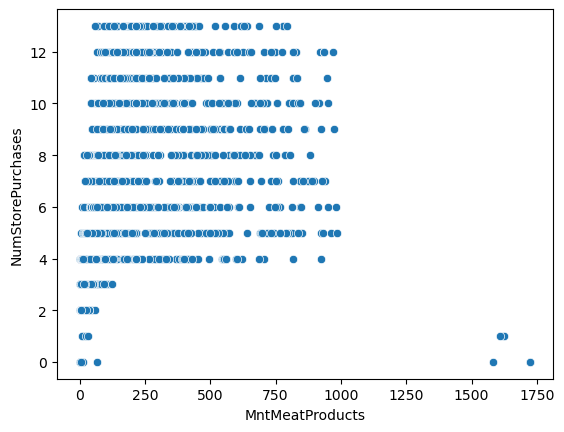

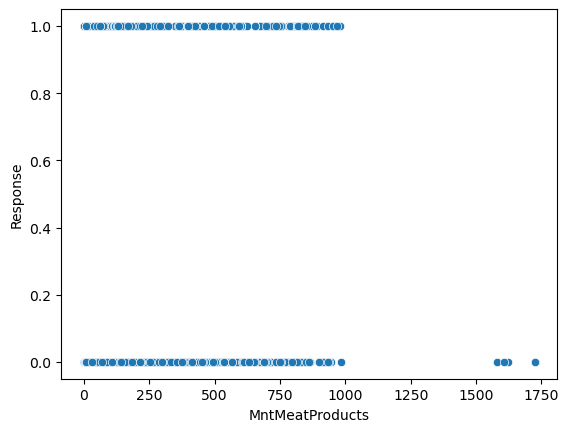

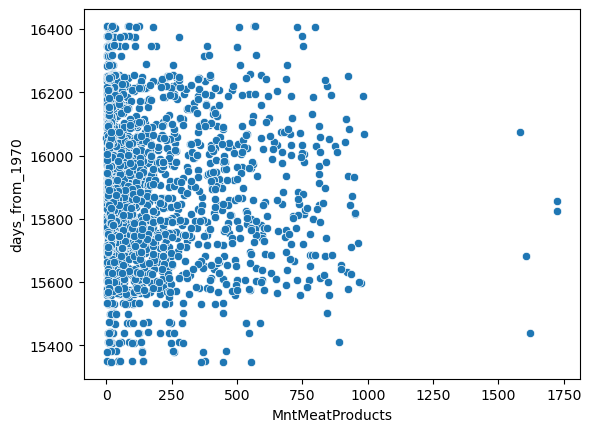

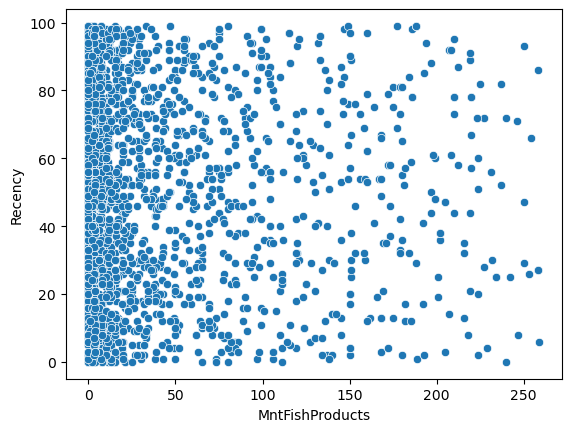

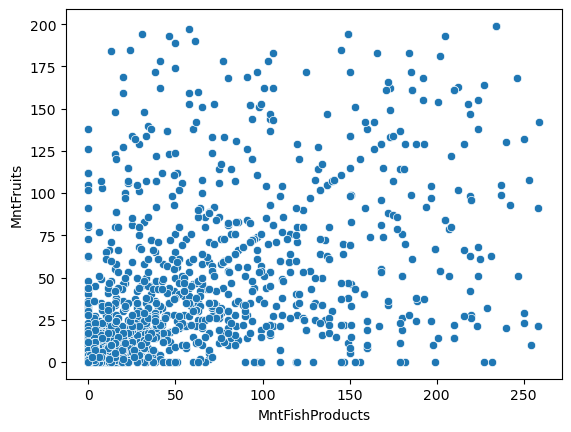

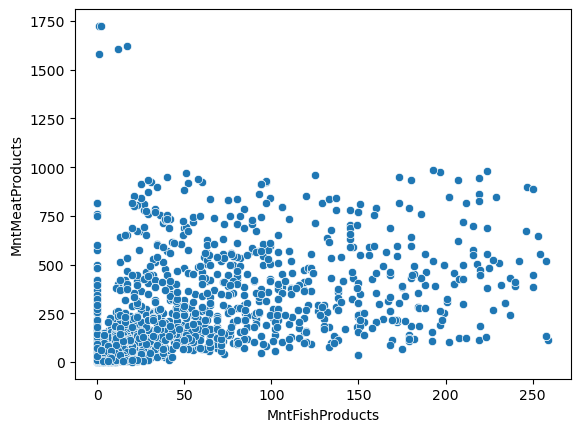

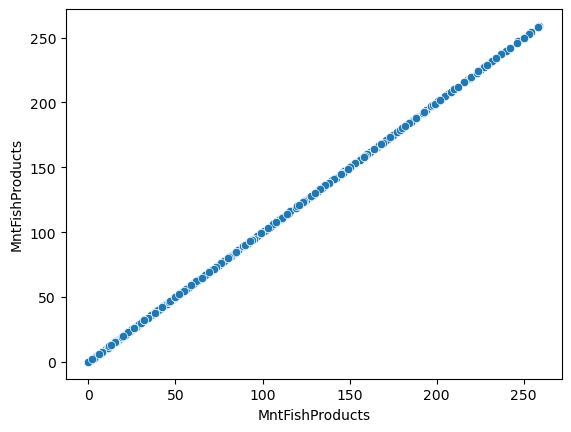

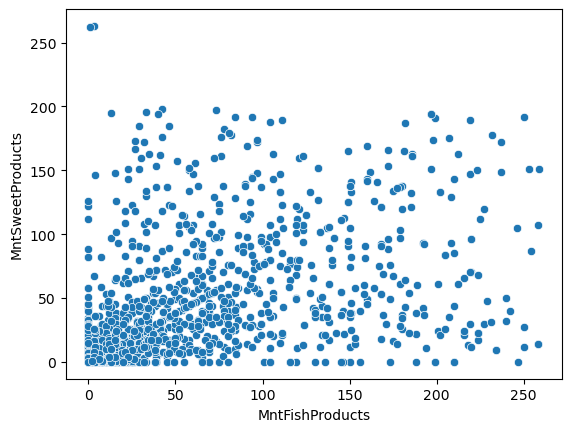

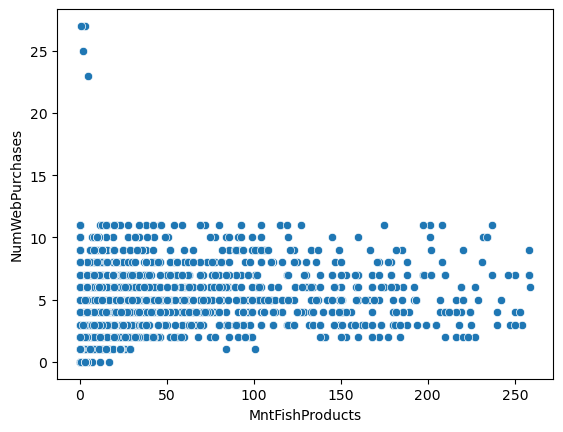

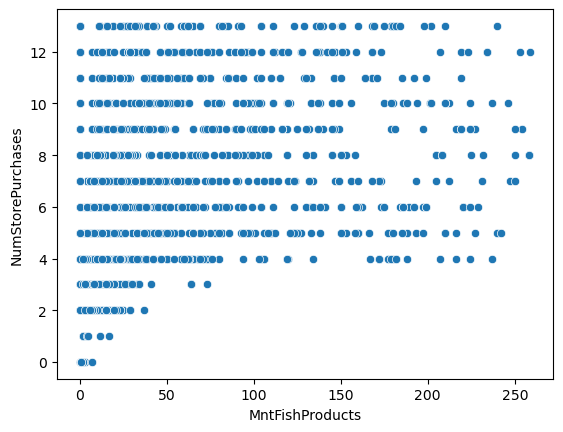

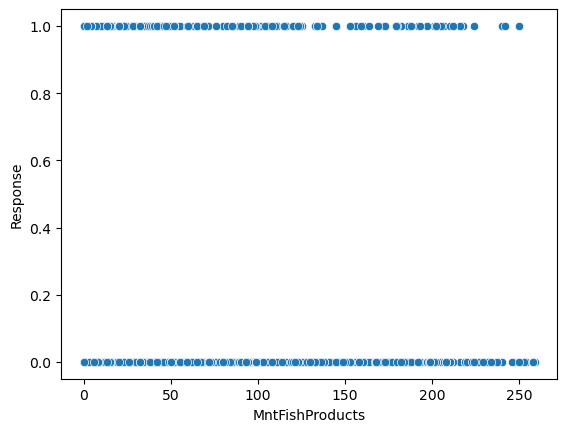

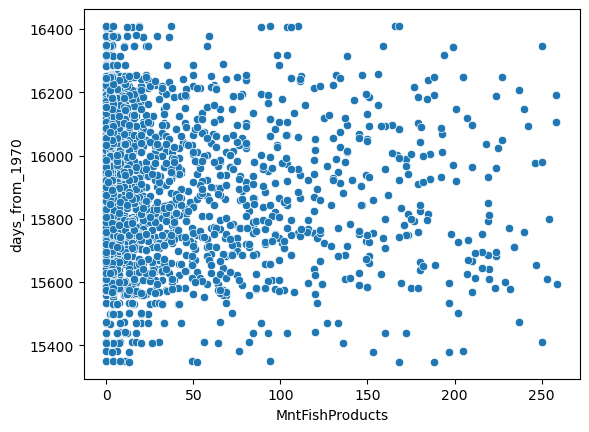

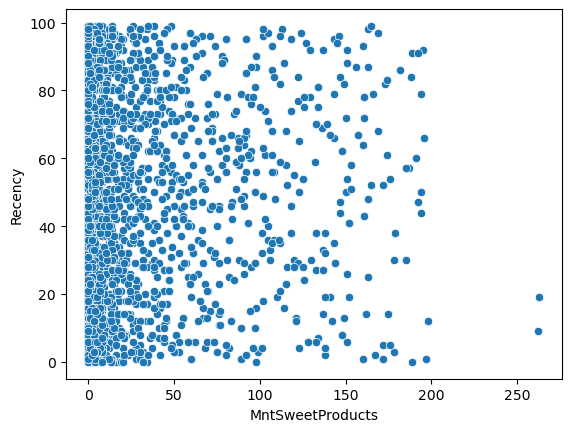

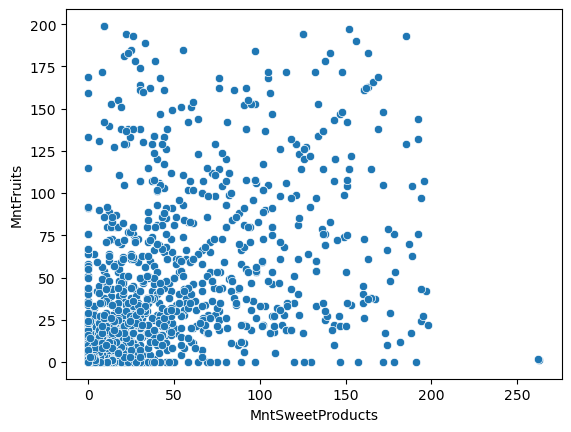

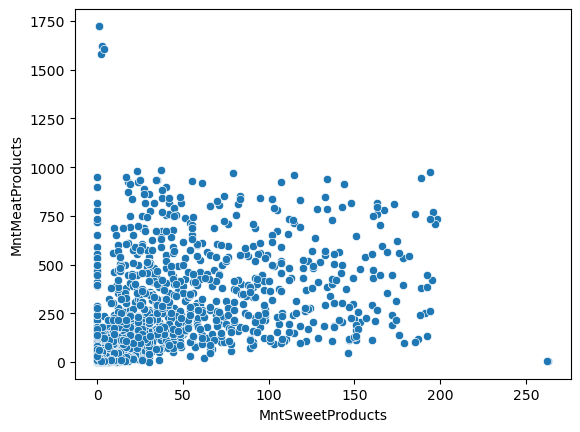

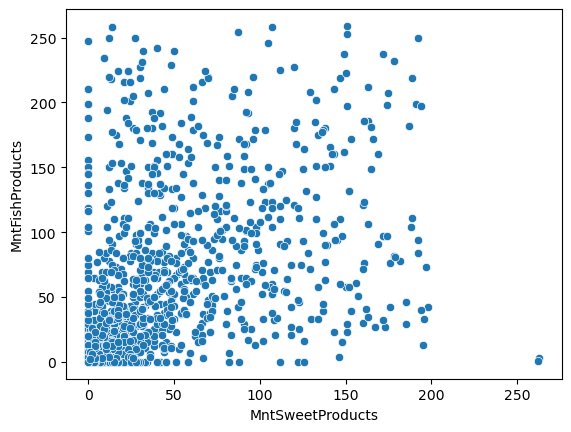

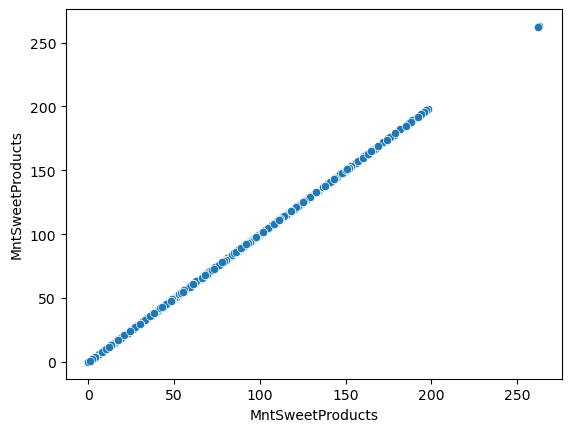

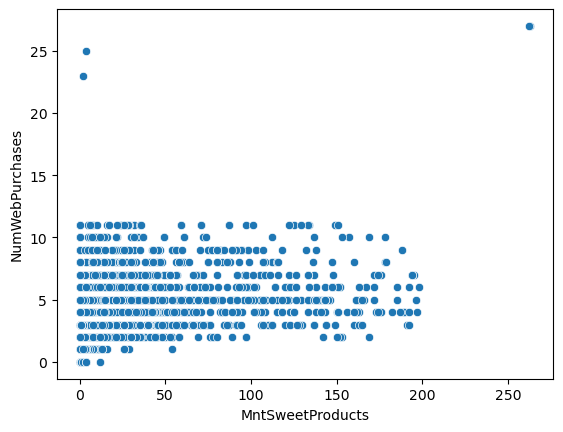

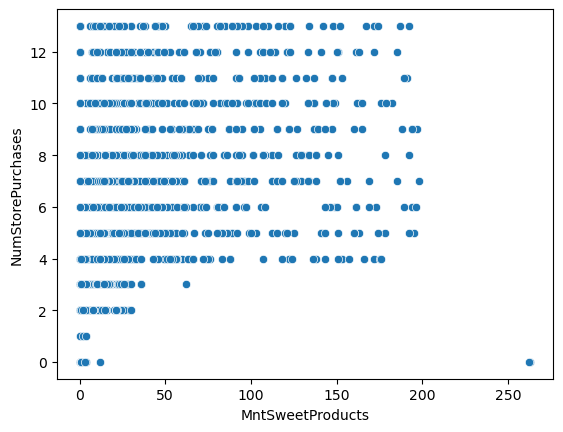

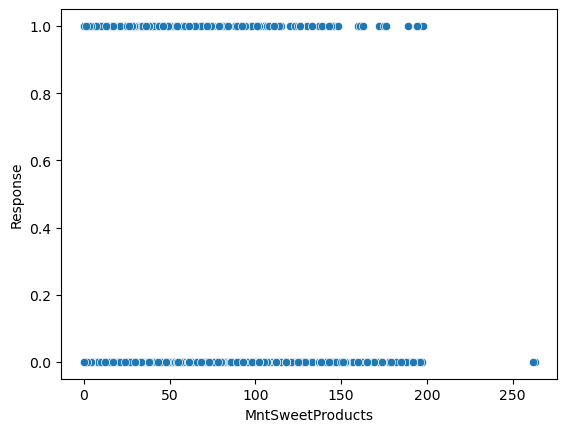

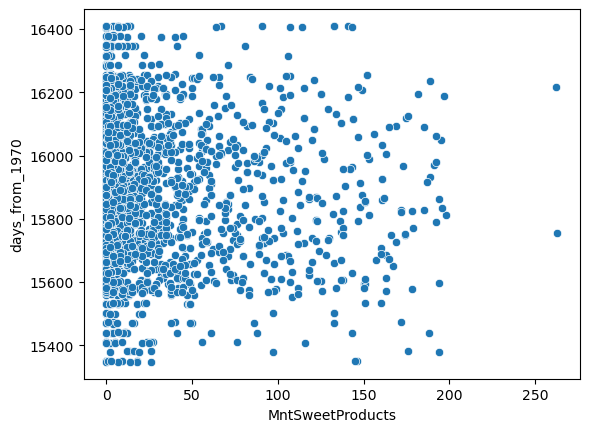

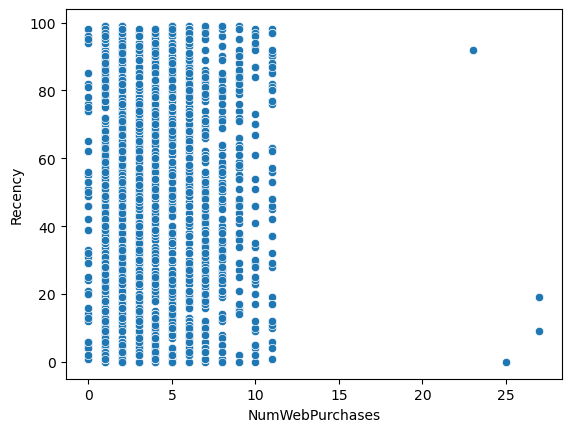

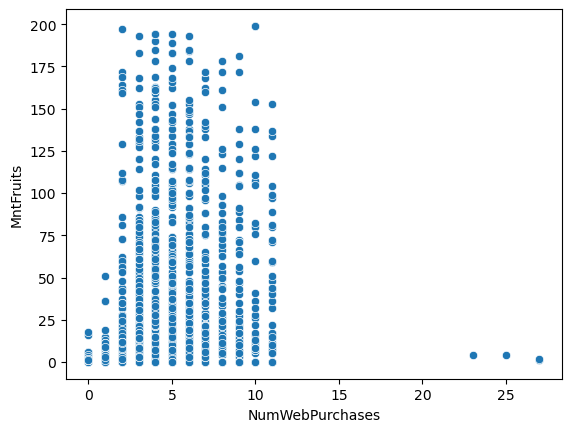

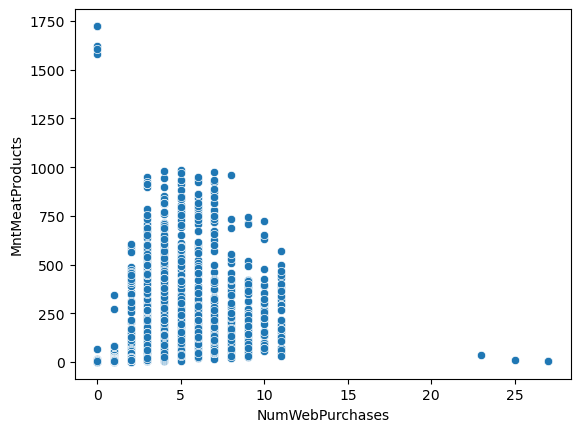

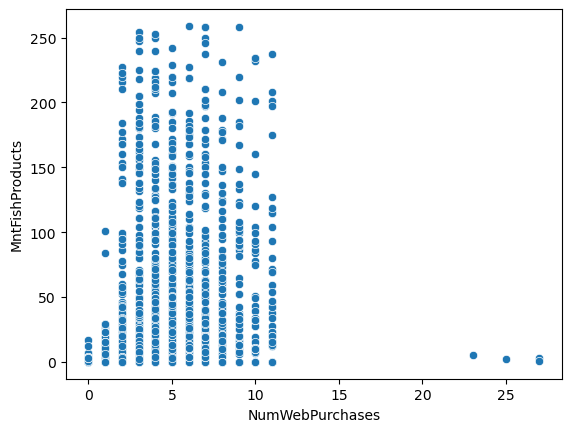

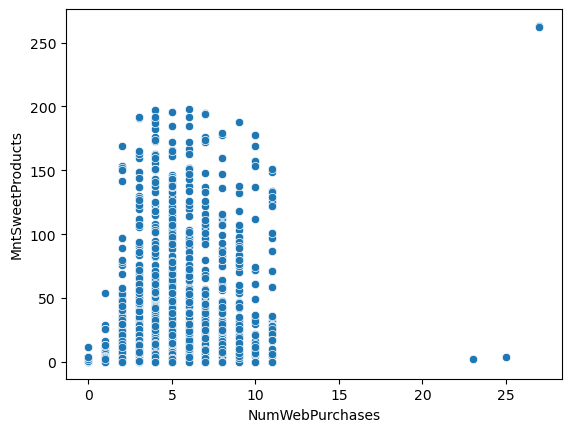

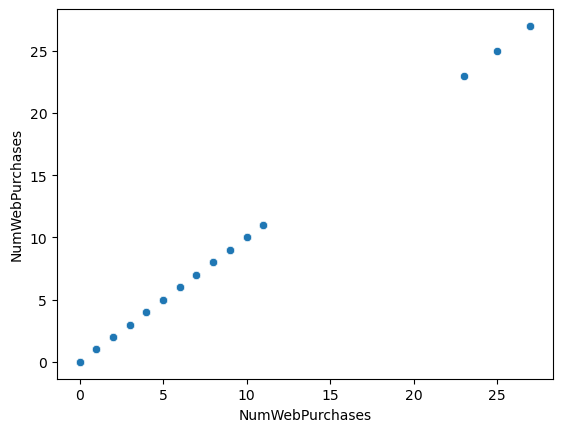

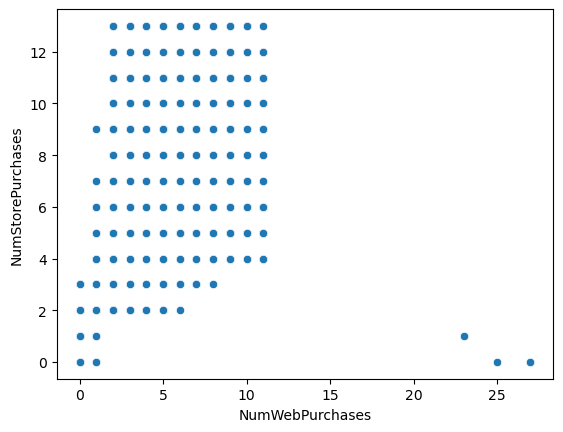

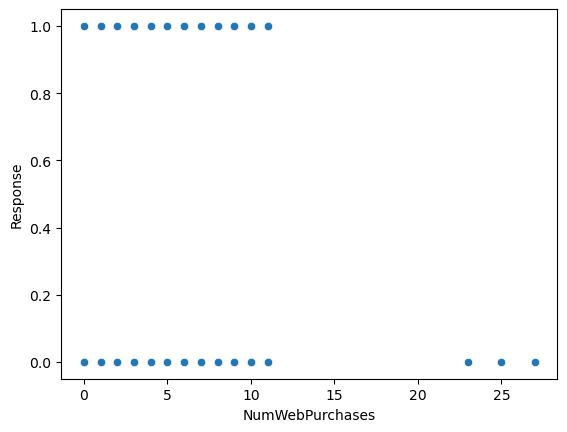

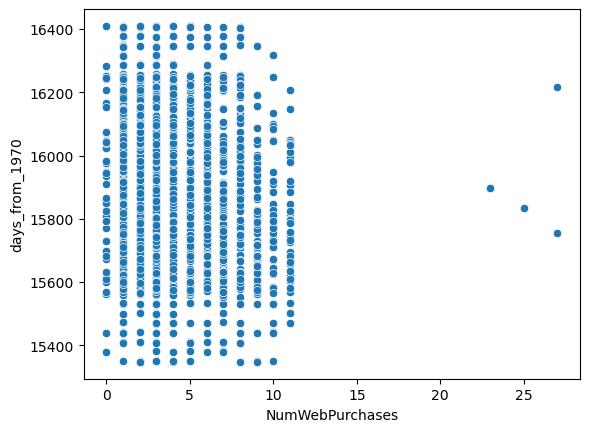

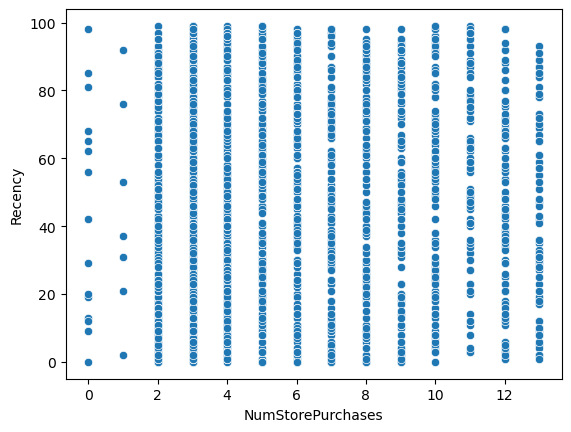

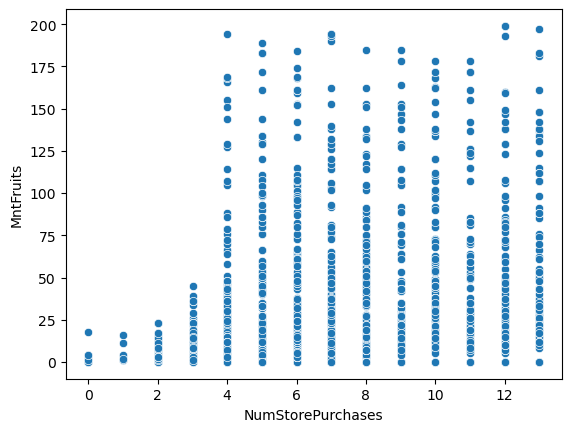

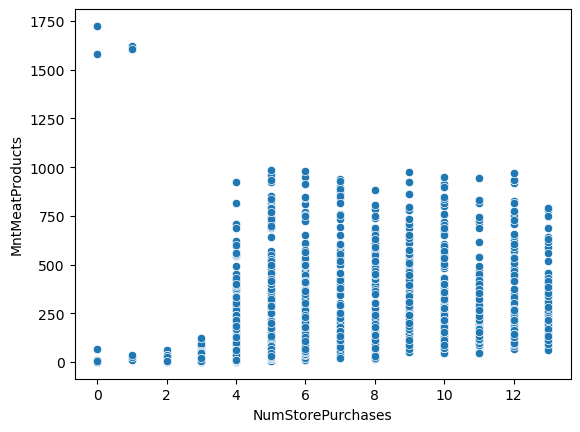

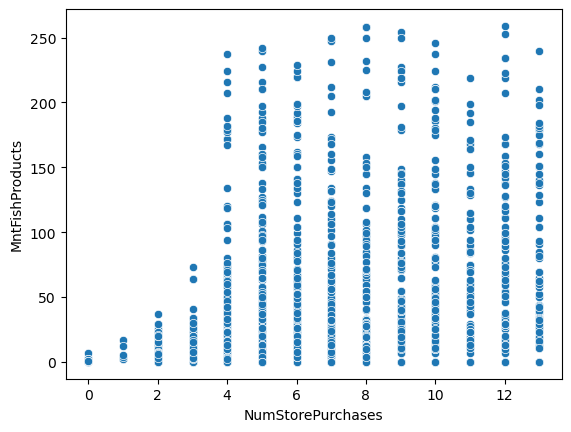

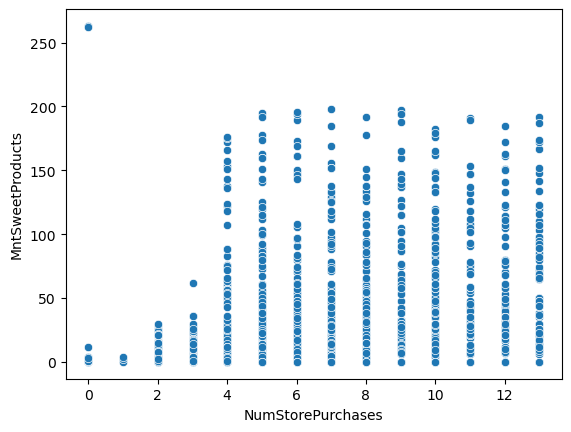

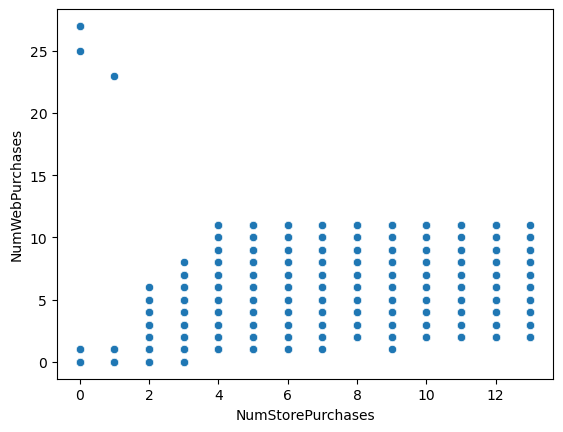

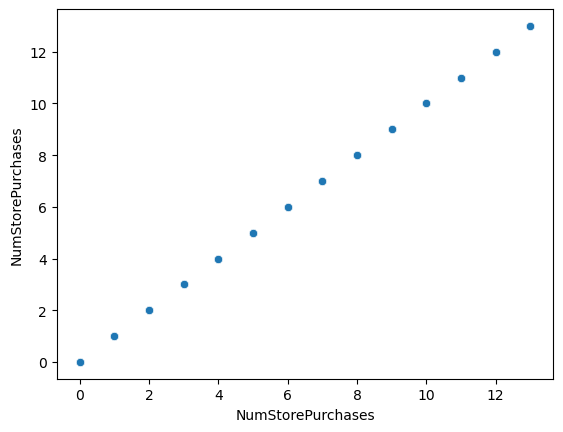

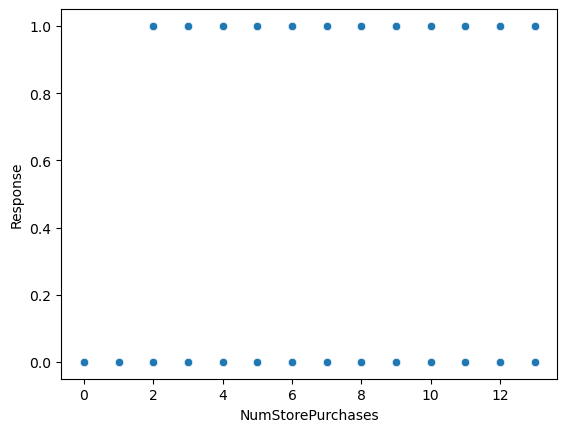

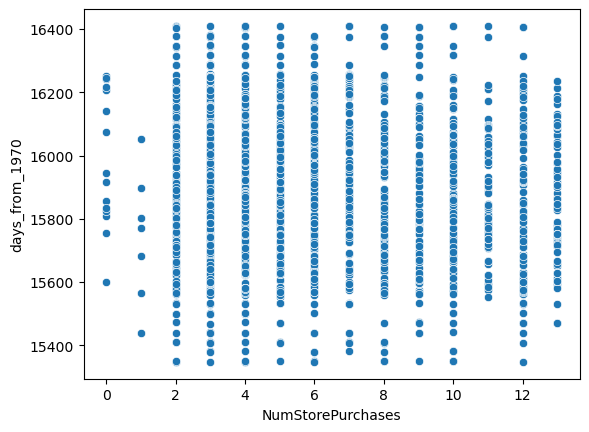

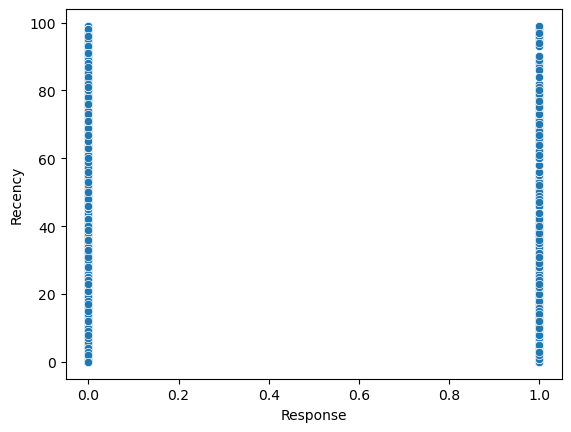

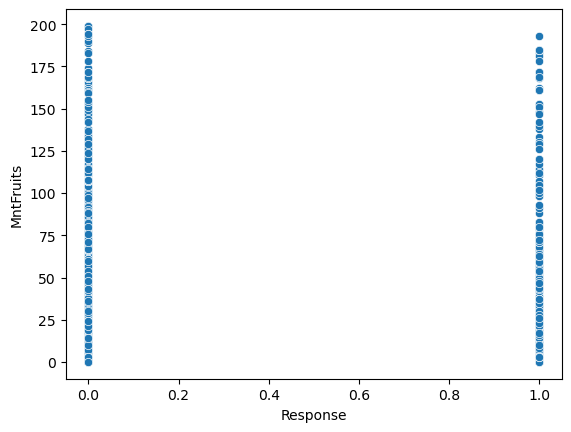

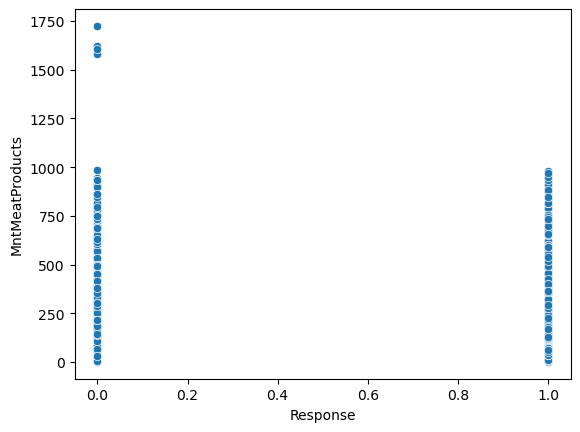

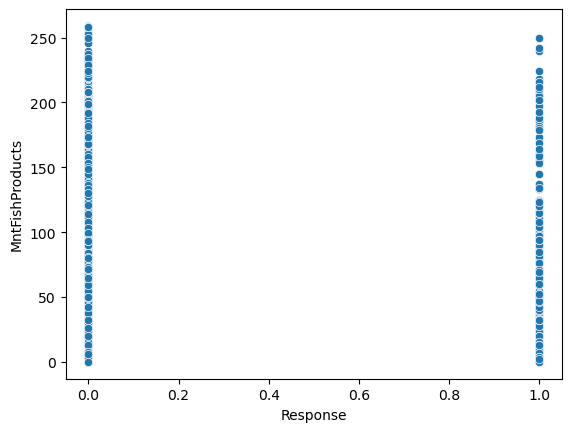

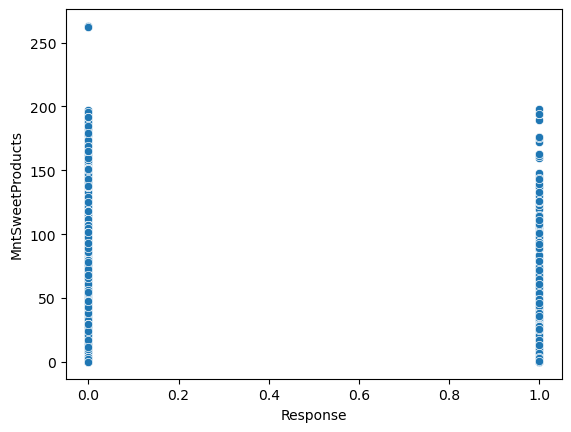

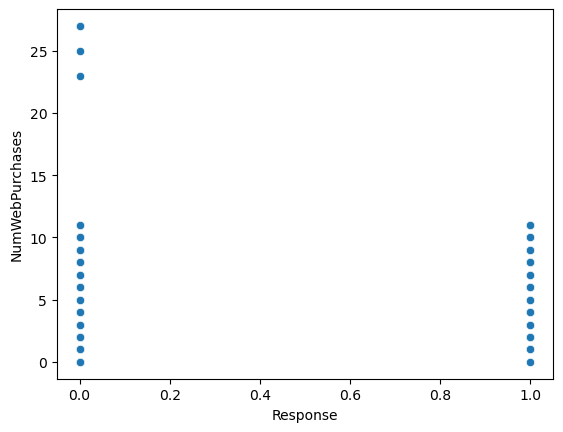

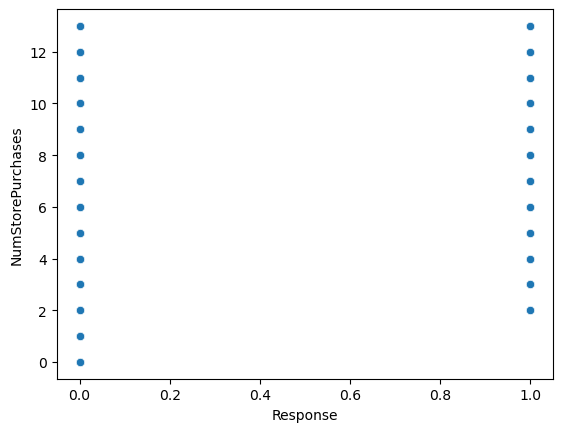

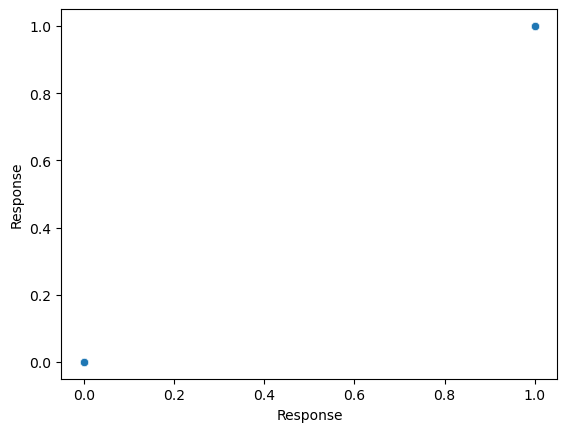

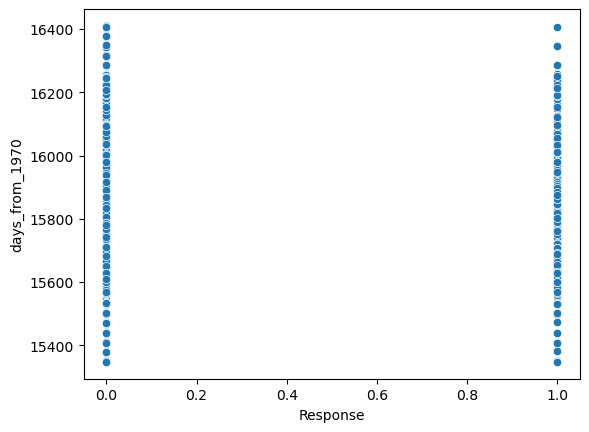

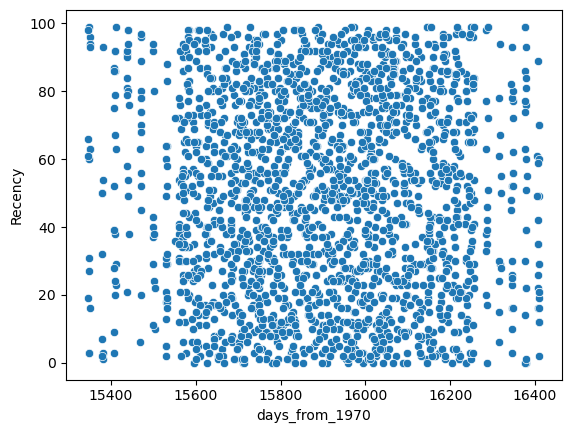

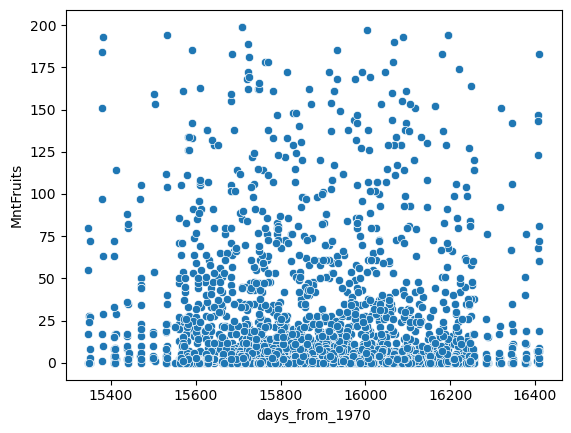

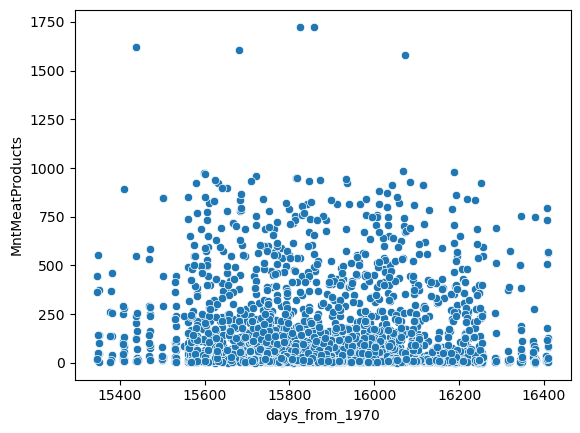

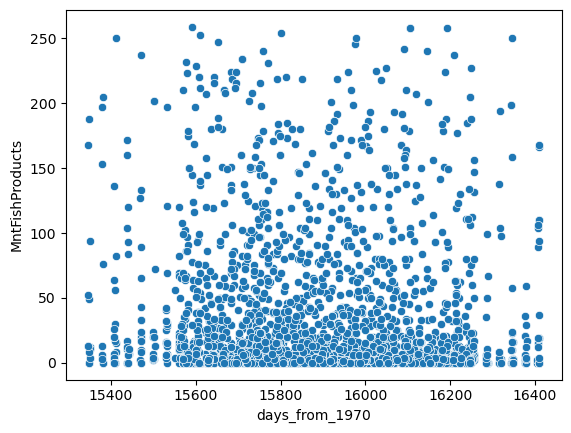

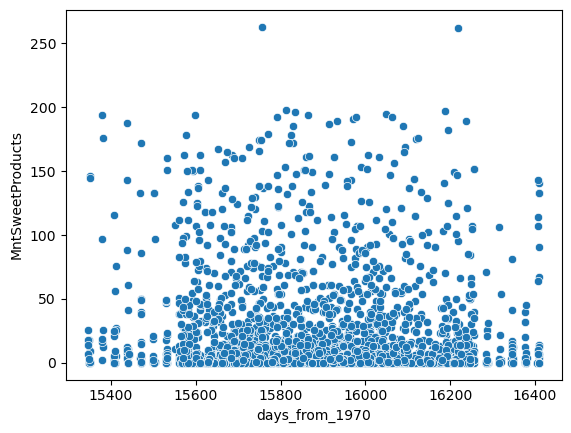

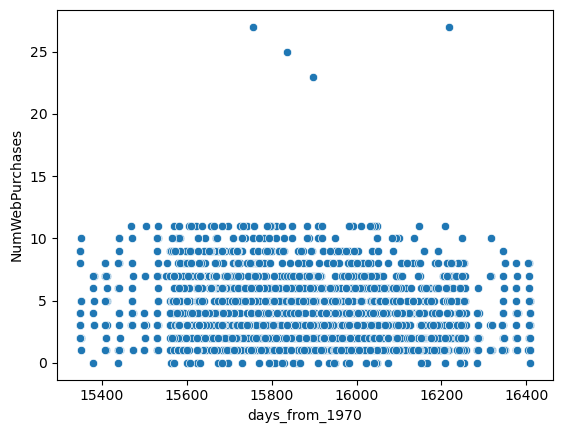

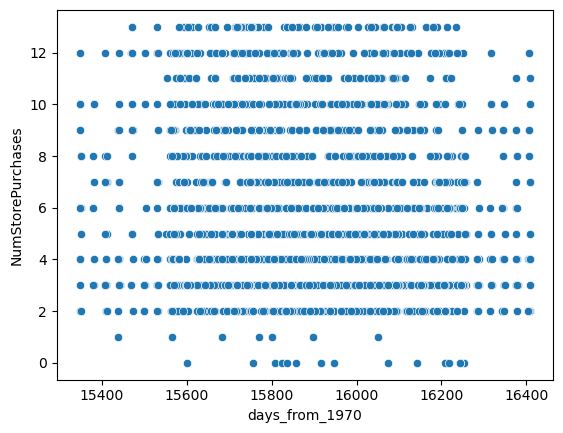

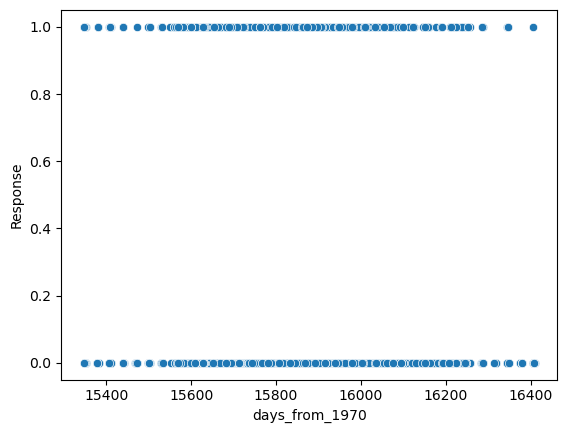

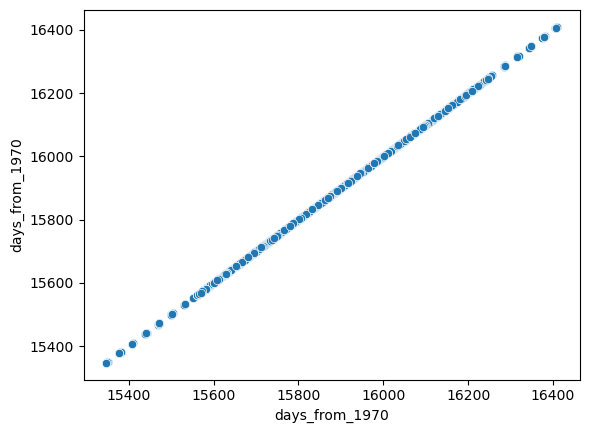

In [10]:
numerical_features = df_new.select_dtypes(include=['int64', 'float64']).columns
for i in range(2, len(numerical_features)):
    for j in range(2, len(numerical_features)):
        sns.scatterplot(x=numerical_features[i], y=numerical_features[j], data=df_new)
        plt.show()

In [11]:
#в датасете имеются выбросы. не наблюдается явных зависимостей между признаками

### Задание 2

Метод k-средних требует явно задать количество кластеров, на которые будут разбиваться данные. Данных может быть так много, что построение одной модели будет занимать несколько часов, поэтому важно заранее примерно представлять количество кластеров до запуска обучения модели.

На основе проведённого разведочного анализа данных предположите, какое количество кластеров будет оптимальным, аргументируйте своё предположение.

Напишите ваш ответ ниже


In [12]:
#Оптимальным будет количество кластеров равное 3, по объему покупок(низкий, средний, высокий)


# Задание 3

Выполните очистку и подготовку данных для дальнейшего использования при построении моделей машинного обучения. Аргументируйте выбранные шаги подготовки данных. 

In [13]:
#Данные могут иметь разные единицы измерения и диапазоны значений. Поэтому произведем нормализацию данных, 
#чтобы они имели одинаковый масштаб.

In [14]:
scaler = StandardScaler()
X_train = df_new.drop(['ID'], axis=1)
X_train_s = scaler.fit_transform(X_train)
X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns)
X_train_s

,Year_Birth,Recency,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,NumWebPurchases,NumStorePurchases,Response,days_from_1970
0,-0.985345,0.307039,1.551577,1.679702,2.462147,1.476500,1.409304,-0.550785,2.388846,-1.976745
1,-1.235733,-0.383664,-0.636301,-0.713225,-0.650449,-0.631503,-1.110409,-1.166125,-0.418612,1.667011
2,-0.317643,-0.798086,0.570804,-0.177032,1.345274,-0.146905,1.409304,1.295237,-0.418612,0.172468
3,1.268149,-0.798086,-0.560857,-0.651187,-0.503974,-0.583043,-0.750450,-0.550785,-0.418612,1.925433
4,1.017761,1.550305,0.419916,-0.216914,0.155164,-0.001525,0.329427,0.064556,-0.418612,0.822831
...,...,...,...,...,...,...,...,...,...,...
2235,-0.150717,-0.107383,0.419916,0.066692,0.081926,2.203398,1.769263,-0.550785,-0.418612,-0.124718
2236,-1.903435,0.237969,-0.661449,-0.606873,-0.687068,-0.655733,1.409304,-0.243114,-0.418612,1.942661
2237,1.017761,1.446700,0.545656,0.221789,-0.101168,-0.364974,-0.750450,2.218248,-0.418612,0.848673
2238,-1.068807,-1.419719,0.092992,0.208495,0.777683,0.071165,0.689386,1.295237,-0.418612,0.844366


# Задание 4

Постройте модель кластеризации с помощью метода k-средних. Определите оптимальное количество кластеров с помощью метода локтя и метрики silhouette score. 

Помните, что аналитический способ определения количества кластеров не является единственно верным. Если ваше понимание предметной области и результаты анализа данных расходятся с результатами метода локтя, вы можете выбрать и обосновать количество кластеров, исходя из своего опыта.

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


<Axes: >

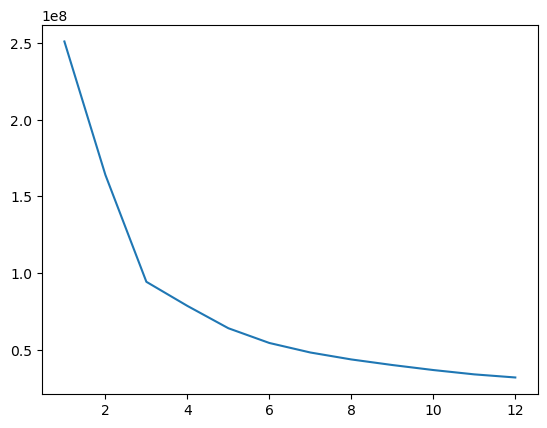

In [15]:
X_train_s = X_train.values

# Определяем количество кластеров
n_clusters = list(range(1, 13))

metrics = []

for k in n_clusters:
  km = KMeans(n_clusters=k, random_state=63,).fit(X_train)
  metrics.append(km.inertia_)


sns.lineplot(x=n_clusters, y=metrics)

In [16]:
n_clusters = list(range(2, 13))
metrics = []
for k in n_clusters:
  km = KMeans(n_clusters=k).fit(X_train)
  score = silhouette_score(X_train_s, km.labels_)
  metrics.append(score)

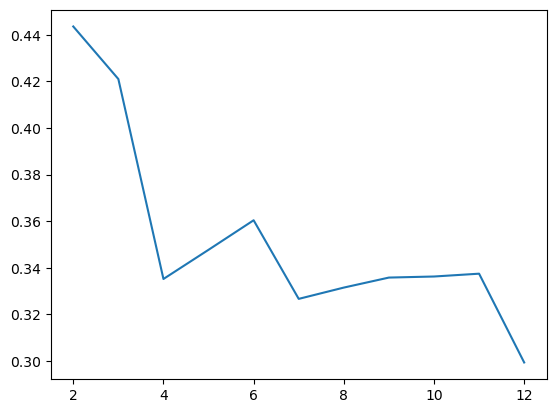

In [17]:
sns.lineplot(x=n_clusters, y=metrics);


# Задание 5

Визуализируйте результаты кластеризации на двумерном графике с помощью метода t-SNE. Обоснуйте выбранные значения его гиперпараметров.

In [18]:
km = KMeans(n_clusters=3).fit(X_train_s)
labels = km.labels_

tsne = TSNE(n_components=2, perplexity=35)
df_emb = tsne.fit_transform(X_train_s)
data = pd.DataFrame(df_emb)
data

,0,1
0,32.973030,12.533045
1,-29.059082,38.643230
2,-3.119529,-0.140106
3,-23.133083,42.572277
4,-17.378481,9.170341
...,...,...
2235,3.034546,-6.458499
2236,-24.678465,43.186680
2237,-12.228774,9.651706
2238,-7.523644,9.618504


<Axes: xlabel='0', ylabel='1'>

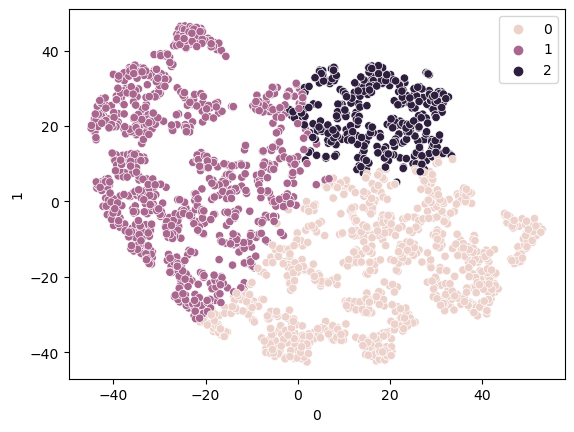

In [19]:
sns.scatterplot(x=data[0], y=data[1], hue=labels)

# Задание 6

Постройте профили кластеров и опишите их.

In [20]:
centroids = km.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=X_train.columns)
centroids_df

,Year_Birth,Recency,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,NumWebPurchases,NumStorePurchases,Response,days_from_1970
0,1969.087568,49.177297,21.011892,92.805405,28.950270,21.921081,4.358919,5.602162,0.168649,15701.113514
1,1968.416228,48.420443,16.106428,73.328767,22.522655,15.749210,3.414120,5.029505,0.067439,16094.545838
2,1969.103825,50.724044,66.109290,597.087432,98.098361,69.393443,5.131148,8.237705,0.311475,15885.707650


In [36]:
class_pred = km.predict(X_train_s)
df_new['class'] = class_pred
df_new

,ID,Year_Birth,Recency,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,NumWebPurchases,NumStorePurchases,Response,days_from_1970,class
0,5524,1957,58,88,546,172,88,8,4,1,15439,2
1,2174,1954,38,1,6,2,1,1,2,0,16285,1
2,4141,1965,26,49,127,111,21,8,10,0,15938,1
3,6182,1984,26,4,20,10,3,2,4,0,16345,1
4,5324,1981,94,43,118,46,27,5,6,0,16089,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,46,43,182,42,118,9,4,0,15869,0
2236,4001,1946,56,0,30,0,0,8,5,0,16349,1
2237,7270,1981,91,48,217,32,12,2,13,0,16095,1
2238,8235,1956,8,30,214,80,30,6,10,0,16094,1


In [38]:
features = ['Year_Birth', 'Recency', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 
            'NumWebPurchases', 'NumStorePurchases', 'Response', 'days_from_1970']

df_g = df_new.groupby('class').agg({x: ['mean', 'std'] for x in features}).T
df_g

class                              0             1             2
Year_Birth        mean   1969.087568   1968.416228   1969.103825
                  std      11.402414     11.776335     13.819388
Recency           mean     49.177297     48.420443     50.724044
                  std      28.417514     29.157821     29.819876
MntFruits         mean     21.011892     16.106428     66.109290
                  std      33.948887     30.894510     48.755853
MntMeatProducts   mean     92.805405     73.328767    597.087432
                  std      94.492979     94.084740    211.385703
MntFishProducts   mean     28.950270     22.522655     98.098361
                  std      43.745423     41.475665     67.405875
MntSweetProducts  mean     21.921081     15.749210     69.393443
                  std      35.909447     29.796042     51.831004
NumWebPurchases   mean      4.358919      3.414120      5.131148
                  std       2.967143      2.610481      2.218049
NumStorePurchases mean      5.602162      5.029505      8.237705
                  std       3.210777      2.975848      2.851733
Response          mean      0.168649      0.067439      0.311475
                  std       0.374644      0.250914      0.463731
days_from_1970    mean  15701.113514  16094.545838  15885.707650
                  std     130.770896    129.612581    212.301799

In [41]:
functions = ['mean', 'std']

stat = np.array([[df_new[feature].apply(f) for f in functions] for feature in features]).flatten()

df_g_rel = df_g.copy()
df_g_rel['Global'] = stat
df_g_rel

class                              0             1             2        Global
Year_Birth        mean   1969.087568   1968.416228   1969.103825   1968.805804
                  std      11.402414     11.776335     13.819388     11.984069
Recency           mean     49.177297     48.420443     50.724044     49.109375
                  std      28.417514     29.157821     29.819876     28.962453
MntFruits         mean     21.011892     16.106428     66.109290     26.302232
                  std      33.948887     30.894510     48.755853     39.773434
MntMeatProducts   mean     92.805405     73.328767    597.087432    166.950000
                  std      94.492979     94.084740    211.385703    225.715373
MntFishProducts   mean     28.950270     22.522655     98.098361     37.525446
                  std      43.745423     41.475665     67.405875     54.628979
MntSweetProducts  mean     21.921081     15.749210     69.393443     27.062946
                  std      35.909447     29.796042     51.831004     41.280498
NumWebPurchases   mean      4.358919      3.414120      5.131148      4.084821
                  std       2.967143      2.610481      2.218049      2.778714
NumStorePurchases mean      5.602162      5.029505      8.237705      5.790179
                  std       3.210777      2.975848      2.851733      3.250958
Response          mean      0.168649      0.067439      0.311475      0.149107
                  std       0.374644      0.250914      0.463731      0.356274
days_from_1970    mean  15701.113514  16094.545838  15885.707650  15897.956696
                  std     130.770896    129.612581    212.301799    232.229893

In [42]:
cluster_labels = [0, 1, 2]

for label in cluster_labels:
  df_g_rel[label] = 100 * df_g_rel[label] / df_g_rel['Global'] - 100

# Задание 7

Визуализируйте профили кластеров. Подготовьте краткое резюме результатов вашего исследования для заказчика.

<Axes: xlabel='class', ylabel='None-None'>

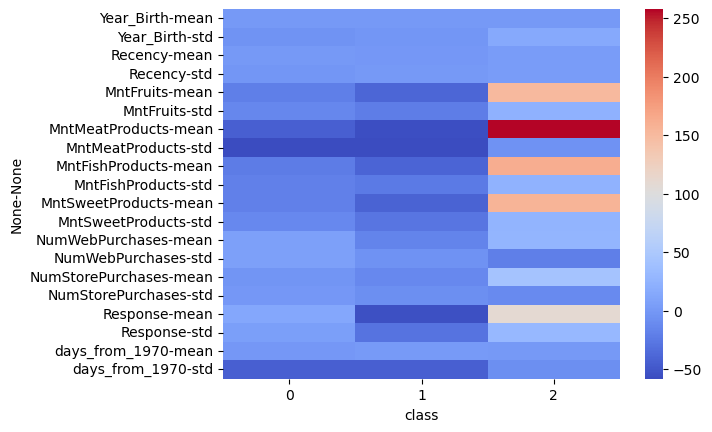

In [43]:
sns.heatmap(df_g_rel[cluster_labels], cmap='coolwarm')

## Как отправить работу на проверку

Скачайте файл с заданием в материалах, откройте его через Jupyter Notebook и выполните задания. Сохраните изменения при помощи опции Save and Checkpoint из вкладки меню File или кнопки Save and Checkpoint на панели инструментов. Отправьте через форму ниже итоговый файл Jupyter Notebook (.ipynb) или ссылку на него.